# Performance Analysis - Study 1

## Loading the libraries

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import itertools
from scipy import stats

## Loading the data

In [2]:
df = pd.read_csv('./processed/ageRisk_long.csv', index_col=0)

## Fetching performance data & calculating performance measures

In [43]:
benchmark_ticker = 'VT'
start_date = '2023-07-01'
end_date = '2025-01-01' # we calculate the performance over the 6 month following the financial advice data collection
market_data = {}

# Fetches the risk free rate from FRED 
def fetch_risk_free_rate():
    risk_free_data = web.DataReader("DGS10", "fred").loc[start_date:end_date]
    risk_free_rate = risk_free_data.mean() / 100
    risk_free_rate = risk_free_rate['DGS10']
    return risk_free_rate
    
risk_free_rate = fetch_risk_free_rate()
num_weeks = len(pd.date_range(start=start_date, end=end_date, freq='W'))
risk_free_weekly = risk_free_rate / num_weeks

In [60]:
# Fetches pricing data for assets from Yahoo Finance
def get_market_data(tickers):
    for ticker in tickers:
        if ticker in market_data:
            return
        else:
            try:
                prices = yf.download(ticker, start=start_date, end=end_date)['Adj Close']
                market_data[ticker] = prices
            except:
                market_data[ticker] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                                  index=market_data[next(iter(market_data))].index)
    

def get_portfolio_data(df, group_cols):
    get_market_data(df['ticker_symbol'].dropna().unique())

    portfolio_df = []  # For time-series data
    summary_df = []  # For final summary values

    grouped = df.groupby(group_cols)

    for name, group in grouped:
        total_investment = group['amount_to_invest'].sum()
        weights = group['amount_to_invest'] / total_investment
        prices_df = pd.DataFrame()
        
        for i, ticker in enumerate(group['ticker_symbol']):
            if ticker in market_data:
                prices_df[ticker] = market_data[ticker]
            else:
                # Assume no return and no standard deviation for invalid/ Nan tickers
                prices_df[f'{ticker}_{i}'] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                              index=market_data[next(iter(market_data))].index)
            
        prices_df = prices_df.ffill().bfill().fillna(1) # fill the price value for equities on the weekend with the last price for portfolios with cryptos 
        
        # Calculate daily portfolio returns
        daily_returns = prices_df.pct_change().fillna(0)
        portfolio_returns = (daily_returns * weights.values).sum(axis=1)

        ## Calculate the weekly returns
        weekly_returns = portfolio_returns.resample('W').sum()

        # Rolling weekly volatility
        rolling_std = portfolio_returns.resample('W').std()
        
        # Rolling weekly Sharpe ratio
        rolling_sharpe = np.where(rolling_std == 0, np.nan, (weekly_returns - risk_free_weekly) / rolling_std)

        df_temp = pd.DataFrame({
            'ai': name[0],
            'age': name[1],
            'risk-taking': name[2],
            'iteration': name[3],
            'date': weekly_returns.index,
            'portfolio_return': weekly_returns.values,
            'portfolio_std_dev': rolling_std.values,
            'sharpe_ratio': rolling_sharpe,
        })
        portfolio_df.append(df_temp)

        # Calculate final summary statistics
        cumulative_returns = (prices_df.iloc[-1] / prices_df.iloc[0]) - 1
        weights.index = cumulative_returns.index
        final_portfolio_return = (cumulative_returns * weights).sum()
        
        cov_matrix = daily_returns.cov()
        portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
        portfolio_std_dev = np.sqrt(portfolio_variance)
        final_sharpe = (final_portfolio_return - risk_free_rate) / portfolio_std_dev

        summary_df.append({
            'ai': name[0],
            'age': name[1],
            'risk-taking': name[2],
            'iteration': name[3],
            'portfolio_return': final_portfolio_return,
            'portfolio_std_dev': portfolio_std_dev,
            'sharpe': final_sharpe
        })

    return pd.concat(portfolio_df, ignore_index=True), pd.DataFrame(summary_df)

def get_benchmark_performance_data(ticker):
    get_market_data([ticker])
    prices_df = pd.DataFrame()
    prices_df[ticker]  = market_data[ticker]
    
    prices = prices_df.pct_change().fillna(0)
    benchmark_returns = prices.sum(axis=1)

    ## Calculate the weekly returns
    weekly_returns = benchmark_returns.resample('W').sum()

    # Rolling weekly volatility
    rolling_std = benchmark_returns.resample('W').std()
    
    # Rolling weekly Sharpe ratio
    rolling_sharpe = np.where(rolling_std == 0, np.nan, (weekly_returns - risk_free_weekly) / rolling_std)

    portfolio_df = pd.DataFrame({
                'date': weekly_returns.index,
                'portfolio_return': weekly_returns.values,
                'portfolio_std_dev': rolling_std.values,
                'sharpe_ratio': rolling_sharpe,
            })

    # Calculate final summary statistics
    cumulative_return = (prices_df['VT'].iloc[-1] / prices_df['VT'].iloc[0]) - 1
    returns_df = prices_df['VT'].pct_change()
    std_dev = returns_df.std()
    sharpe = (cumulative_return - risk_free_rate) / std_dev
    
    summary_df = pd.DataFrame({
        'portfolio_return': [cumulative_return],
        'portfolio_std_dev': [std_dev],
        'sharpe': [sharpe]
    })
    
    return portfolio_df, summary_df

# Get time-series data and final summary values
group_cols = ['ai', 'age', 'risk-taking', 'iteration']    
portfolio_time_series_df, portfolio_summary_df = get_portfolio_data(df, group_cols)
benchmark_time_series_df, benchmark_summary_df = get_benchmark_performance_data(benchmark_ticker)

# Save performance data
portfolio_time_series_df.to_csv('./processed/performance_weekly.csv')
portfolio_summary_df.to_csv('./processed/performance_summary.csv')
benchmark_time_series_df.to_csv('./processed/benchmark_performance_weekly.csv')
benchmark_summary_df.to_csv('processed/benchmark_performance_summary.csv')

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_21662/2235482727.py:71: RuntimeWarning: divide by zero encountered in scalar divide
  final_sharpe = (final_portfolio_return - risk_free_rate) / portfolio_std_dev


## Analysis

In [64]:
portfolios_timeseries = pd.read_csv('./processed/performance_weekly.csv', index_col=0)
portfolios_timeseries['date'] = pd.to_datetime(portfolios_timeseries['date'])
portolios_summary = pd.read_csv('./processed/performance_summary.csv', index_col=0)
benchmark_timeseries = pd.read_csv('./processed/benchmark_performance_weekly.csv', index_col=0)
benchmark_timeseries['date'] = pd.to_datetime(benchmark_timeseries['date'])
benchmark_summary = pd.read_csv('./processed/benchmark_performance_summary.csv', index_col=0)

In [65]:
portfolios_timeseries.head()

,ai,age,risk-taking,iteration,date,portfolio_return,portfolio_std_dev,sharpe_ratio
0,ChatGPT,15,averse,0,2023-07-09,-0.017534,0.004567,-3.956737
1,ChatGPT,15,averse,0,2023-07-16,0.012339,0.002171,5.436596
2,ChatGPT,15,averse,0,2023-07-23,0.025927,0.006853,3.704946
3,ChatGPT,15,averse,0,2023-07-30,0.008975,0.005430,1.554066
4,ChatGPT,15,averse,0,2023-08-06,-0.016612,0.003957,-4.333653


In [74]:
import seaborn as sns

def plot_timeline(raw, column, groups):
    grouped = raw.groupby(groups, observed=False)[column].mean().reset_index()
    grouped = grouped.sort_values(by='date')
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=grouped, x='date', y=column, hue='ai', marker="o", linewidth=2.5)
    
    # Formatting
    plt.xlabel('Date')
    plt.ylabel('Portfolio Return')
    plt.xticks(rotation=45)
    plt.legend(title="AI Model")
    
    # Show the plot
    plt.show()

    

    

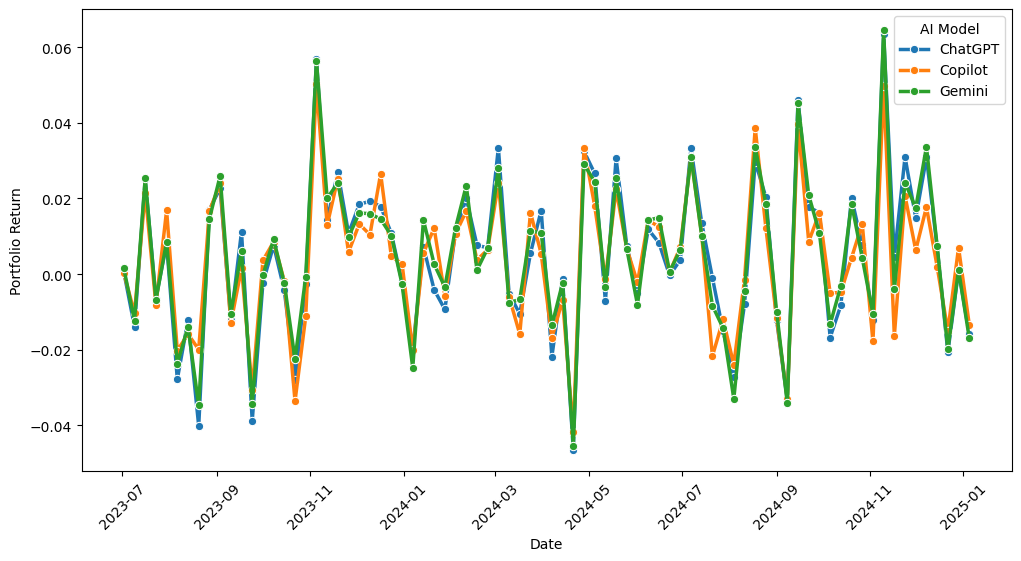

In [75]:
plot_timeline(portfolios_timeseries, 'portfolio_return', ['ai', 'date'])

In [ ]:
def show_anova(df, column, group1, group2=None, onlyGroup=False):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df = df.copy()
        df.loc[:, 'label'] = df.loc[:, group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)

def show_performance_timeline(df, column, group1, group2=None):
    if group2:
        return
    else:
        
        

In [34]:
# Calculates the Sharpe ratio
def calculate_sharpe_ratio(row):
    if (row['portfolio_std_dev'] == 0) and (row['portfolio_return'] == 0):
        return np.nan
    sharpe = (row['portfolio_return'] - risk_free_rate) / row['portfolio_std_dev']
    return sharpe

# Fetches pricing data for assets from Yahoo Finance
def get_market_data(tickers):
    for ticker in tickers:
        try:
            prices = yf.download(ticker, start=start_date, end=end_date)['Adj Close']
            market_data[ticker] = prices
        except:
            market_data[ticker] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                              index=market_data[next(iter(market_data))].index) 

def get_portfolio_data(df, group_cols):
    #get_market_data(df['ticker_symbol'].dropna().unique())

    portfolio_df = []  # For time-series data
    summary_df = []  # For final summary values

    grouped = df.groupby(group_cols)

    for name, group in grouped:
        total_investment = group['amount_to_invest'].sum()
        weights = group['amount_to_invest'] / total_investment
        prices_df = pd.DataFrame()

        for i, ticker in enumerate(group['ticker_symbol']):
            if ticker in market_data:
                prices_df[ticker] = market_data[ticker]
            else:
                # Assume no return and no standard deviation for invalid/ Nan tickers
                prices_df[f'{ticker}_{i}'] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                              index=market_data[next(iter(market_data))].index)

        prices_df = prices_df.ffill().bfill().fillna(1)  # fill the price value for equities on the weekend with the last price for portfolios with cryptos 

        # **Calculate daily portfolio returns**
        daily_returns = prices_df.pct_change().fillna(0)
        portfolio_returns = (daily_returns * weights.values).sum(axis=1)

        ## Calculate the weekly returns
        weekly_returns = portfolio_returns.resample('W').sum()

        print(weekly_returns.head(20))

        # Use risk-free rate adjusted for weekly periods
        risk_free_weekly = risk_free_rate / 52  # Since 52 weeks in a year
        
        # Rolling weekly volatility
        rolling_std = portfolio_returns.resample('W').std()
        print(rolling_std.head(20))
        
        # Rolling weekly Sharpe ratio
        rolling_sharpe = np.where(rolling_std == 0, np.nan, (weekly_returns - risk_free_weekly) / rolling_std)


        df_temp = pd.DataFrame({
            'date': weekly_returns.index,
            'portfolio_return': weekly_returns.values,
            'portfolio_std_dev': rolling_std.values,
            'sharpe_ratio': rolling_sharpe,
            'ai': name[0]
        })
        portfolio_df.append(df_temp)

        # **Calculate final summary statistics**
        cumulative_return = (prices_df.iloc[-1] / prices_df.iloc[0]) - 1
        final_portfolio_return = (cumulative_return * weights).sum()
        cov_matrix = daily_returns.cov()
        portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
        portfolio_std_dev = np.sqrt(portfolio_variance)
        final_sharpe = (final_portfolio_return - risk_free_rate) / portfolio_std_dev

        summary_df.append({
            'ai': name[0],
            'age': name[1],
            'risk-taking': name[2],
            'iteration': name[3],
            'portfolio_return': final_portfolio_return,
            'portfolio_std_dev': portfolio_std_dev,
            'sharpe': final_sharpe
        })

    return pd.concat(portfolio_df, ignore_index=True), pd.DataFrame(summary_df)

# Get time-series data and final summary values
group_cols = ['ai', 'age', 'risk-taking', 'iteration']    
portfolio_time_series_df, portfolio_summary_df = get_portfolio_data(df, group_cols)

# Save summary stats
portfolio_summary_df.to_csv('./processed/performance_summary.csv')

Date
2023-07-09   -0.017534
2023-07-16    0.012339
2023-07-23    0.025927
2023-07-30    0.008975
2023-08-06   -0.016612
2023-08-13    0.008085
2023-08-20   -0.011526
2023-08-27   -0.005914
2023-09-03   -0.006458
2023-09-10   -0.007049
2023-09-17    0.002086
2023-09-24   -0.008330
2023-10-01   -0.023702
2023-10-08   -0.015428
2023-10-15    0.003076
2023-10-22    0.000892
2023-10-29   -0.008982
2023-11-05    0.028107
2023-11-12   -0.005450
2023-11-19    0.011586
Freq: W-SUN, dtype: float64
Date
2023-07-09    0.004567
2023-07-16    0.002171
2023-07-23    0.006853
2023-07-30    0.005430
2023-08-06    0.003957
2023-08-13    0.005088
2023-08-20    0.002756
2023-08-27    0.006385
2023-09-03    0.002850
2023-09-10    0.004787
2023-09-17    0.006013
2023-09-24    0.005023
2023-10-01    0.003018
2023-10-08    0.006293
2023-10-15    0.005716
2023-10-22    0.002728
2023-10-29    0.007751
2023-11-05    0.003899
2023-11-12    0.004294
2023-11-19    0.003054
Freq: W-SUN, dtype: float64
Date
2023-07-0

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_21662/1408691931.py:76: RuntimeWarning: divide by zero encountered in scalar divide
  final_sharpe = (final_portfolio_return - risk_free_rate) / portfolio_std_dev


Date
2023-07-09   -0.009578
2023-07-16    0.019403
2023-07-23   -0.015787
2023-07-30    0.007077
2023-08-06   -0.018714
2023-08-13   -0.015164
2023-08-20   -0.043539
2023-08-27    0.022823
2023-09-03    0.030677
2023-09-10   -0.008547
2023-09-17    0.011838
2023-09-24   -0.043271
2023-10-01   -0.005466
2023-10-08    0.027492
2023-10-15   -0.002527
2023-10-22   -0.025406
2023-10-29    0.012228
2023-11-05    0.060540
2023-11-12    0.037817
2023-11-19    0.018160
Freq: W-SUN, dtype: float64
Date
2023-07-09    0.002737
2023-07-16    0.011072
2023-07-23    0.014759
2023-07-30    0.012802
2023-08-06    0.010689
2023-08-13    0.006185
2023-08-20    0.010105
2023-08-27    0.016238
2023-09-03    0.012596
2023-09-10    0.009042
2023-09-17    0.014815
2023-09-24    0.008970
2023-10-01    0.011866
2023-10-08    0.016294
2023-10-15    0.007238
2023-10-22    0.013212
2023-10-29    0.018239
2023-11-05    0.007749
2023-11-12    0.011170
2023-11-19    0.008317
Freq: W-SUN, dtype: float64
Date
2023-07-0

In [15]:
portfolio_time_series_df.head(30)

,date,portfolio_return,portfolio_std_dev,sharpe_ratio,ai
0,2023-07-09,-0.017534,NaN,NaN,ChatGPT
1,2023-07-16,0.012339,NaN,NaN,ChatGPT
2,2023-07-23,0.025927,NaN,NaN,ChatGPT
3,2023-07-30,0.008975,NaN,NaN,ChatGPT
4,2023-08-06,-0.016612,NaN,NaN,ChatGPT
5,2023-08-13,0.008085,NaN,NaN,ChatGPT
6,2023-08-20,-0.011526,NaN,NaN,ChatGPT
7,2023-08-27,-0.005914,NaN,NaN,ChatGPT
8,2023-09-03,-0.006458,NaN,NaN,ChatGPT
9,2023-09-10,-0.007049,NaN,NaN,ChatGPT


In [3]:
start_date = '2023-07-01'
end_date = '2025-01-01' # we calculate the performance over the 6 month following the financial advice data collection
market_data = {}

# Fetches the risk free rate from FRED 
def fetch_risk_free_rate():
    risk_free_data = web.DataReader("DGS10", "fred").loc[start_date:end_date]
    risk_free_rate = risk_free_data.mean() / 100
    risk_free_rate = risk_free_rate['DGS10']
    return risk_free_rate
    
risk_free_rate = fetch_risk_free_rate()

In [ ]:
# Calculates the Sharpe ratio
def calculate_sharpe_ratio(row):
    if (row['portfolio_std_dev'] == 0) and (row['portfolio_return'] == 0):
        return np.nan
    sharpe = (row['portfolio_return'] - risk_free_rate) / row['portfolio_std_dev']
    return sharpe

# Fetches pricing data for assets from Yahoo Finance
def get_market_data(tickers):
    for ticker in tickers:
        try:
            prices = yf.download(ticker, start=start_date, end=end_date)['Adj Close']
            market_data[ticker] = prices
        except:
            market_data[ticker] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                              index=market_data[next(iter(market_data))].index) 

# Calculates the portfolio return, portfolio volatility, and portfolio sharpe ratio
def get_portfolio_data(df, group_cols):
    get_market_data(df['ticker_symbol'].dropna().unique())
    portfolio_df = pd.DataFrame(columns=['ai', 'age', 'risk-taking', 'iteration', 'portfolio_return', 'portfolio_std_dev'])
    grouped = df.groupby(group_cols)
    
    for name, group in grouped:
        total_investment = group['amount_to_invest'].sum()
        weights = group['amount_to_invest'] / total_investment
        prices_df = pd.DataFrame()
        for i, ticker in enumerate(group['ticker_symbol']):
            if ticker in market_data:
                prices_df[ticker] = market_data[ticker]
            else:
                # Assume no return and no standard deviation for invalid/ Nan tickers
                prices_df[f'{ticker}_{i}'] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                              index=market_data[next(iter(market_data))].index)
            
        prices_df = prices_df.ffill().bfill().fillna(1) # fill the price value for equities on the weekend with the last price for portfolios with cryptos 

        # Calculate the cumulative portfolio return
        cumulative_returns = (prices_df.iloc[-1] / prices_df.iloc[0]) - 1
        weights.index = cumulative_returns.index
        portfolio_return = (cumulative_returns * weights).sum()

        # Calculate the portfolio volatilty
        returns_df = prices_df.pct_change()
        cov_matrix = returns_df.cov()
        portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
        portfolio_std_dev = np.sqrt(portfolio_variance)
        portfolio_df.loc[len(portfolio_df)] = {
            'ai': name[0],
            'age': name[1],
            'risk-taking': name[2],
            'iteration': name[3],
            'portfolio_return': portfolio_return,
            'portfolio_std_dev': portfolio_std_dev
        }
    return portfolio_df
        
group_cols = ['ai', 'age', 'risk-taking', 'iteration']    
portfolio_df = get_portfolio_data(df, group_cols)
portfolio_df['sharpe'] = portfolio_df.apply(calculate_sharpe_ratio, axis=1)
portfolio_df.to_csv('./processed/performance_features.csv')


## Analysis

In [4]:
portfolio_df = pd.read_csv('./processed/performance_features.csv', index_col=0)
portfolio_df['risk-taking'] = portfolio_df['risk-taking'].replace({'averse':'low', 'neutral':'medium', 'seeking':'high'})
portfolio_df['portfolio_std_dev'] *= 100 # in %
portfolio_df['portfolio_return'] *= 100 # in %

In [5]:
label_dict = {'ai':'GenAI', 'age':'Age', 'risk-taking':'Risk Tendency'}

# Calculates the benchmark return, benchmark volatility, and benchmark sharpe ratio 
def fetch_benchmark_data(ticker):
    prices = yf.download(ticker, start=start_date, end=end_date)['Adj Close']
    cumulative_return = (prices.iloc[-1] / prices.iloc[0]) - 1
    returns_df = prices.pct_change()
    std_dev = returns_df.std()
    sharpe = (cumulative_return - risk_free_rate) / std_dev
    return cumulative_return, std_dev, sharpe

# Calculates and prints an ANOVA and TukeyHSD results
def show_anova(df, column, group1, group2=None):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df['label'] = df[group1]
        
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)

# Calculates and prints t-tests between samples and a fixed benchmark value
def show_ttest(raw, column, groups, benchmark):
    for group_name, group_data in raw.groupby(groups, observed=False):
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark)
        print(f'group: {group_name} got t: {t_statistic} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark, 4)}')
    
# Prints a mean plot relative to a fixed benchmark value
def show_mean_errplot(raw, column, label, benchmark, benchmark_label, group1, group2=None):
    show_anova(raw, column, group1, group2)

    if group1 == 'risk-taking':
        order = ['low', 'medium', 'high']
        raw[group1] = pd.Categorical(raw[group1], categories=order, ordered=True)
        raw.sort_values(by=group1, inplace=True)
    
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups, observed=False)[column]
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()

    standard_errors = std_devs / np.sqrt(sample_sizes)

    print(f'means:\n{round(means, 4)}')
    print(f'stds:\n{round(std_devs,4)}')
    print(sample_sizes)

    colors = ['darkgray']
    if group2:
        colors = ['dimgray', 'darkgray', 'lightgray']
    ax = means.plot(kind='bar', stacked=False, yerr=standard_errors.values.T, capsize=5, figsize=(5, 4), color=colors, zorder=2)
    ax.axhline(y=benchmark, color='black', linestyle='--', zorder=4)
    ax.text(1.02, benchmark, benchmark_label, va='center', ha="left", bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.2'), transform=ax.get_yaxis_transform())

    ax.set_ylabel(label)
    ax.set_xticklabels(means.index, rotation=0, ha='center')
    group1 = label_dict.get(group1, group1)
    ax.set_xlabel(group1)
    ax.grid(True, zorder=1)
    
    if group2:
        group2 = label_dict.get(group2, group2) 
        legend = ax.legend(title=group2, bbox_to_anchor=(1.02, 1), loc='upper left')
        legend.get_title().set_text(group2)

    group2_label = f'-{group2}' if group2 != None else ''
    plt.savefig(f'./figures/performance/{group1}{group2_label}-{label}.png', bbox_inches='tight')
    
    plt.tight_layout()
    plt.show()
    

In [6]:
benchmark_return, benchmark_std, benchmark_sharpe = fetch_benchmark_data('VT')
benchmark_return *= 100 # in %
benchmark_std *= 100 # in %

[*********************100%%**********************]  1 of 1 completed


### Portfolio Return

               sum_sq     df         F    PR(>F)
label      144.135862    2.0  3.280104  0.039146
Residual  5866.319398  267.0       NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
ChatGPT Copilot   0.6957 0.5802 -0.9511 2.3426  False
ChatGPT  Gemini   1.7759 0.0311   0.129 3.4227   True
Copilot  Gemini   1.0802 0.2713 -0.5667  2.727  False
-----------------------------------------------------
group: ('ChatGPT',) got t: -1.1115786284969087 p_value: 0.2693 dfs: 89 benchmark: 7.0324
group: ('Copilot',) got t: 0.35464928605044843 p_value: 0.7237 dfs: 89 benchmark: 7.0324
group: ('Gemini',) got t: 2.991486333871454 p_value: 0.0036 dfs: 89 benchmark: 7.0324
means:
ai
ChatGPT    6.5484
Copilot    7.2441
Gemini     8.3243
Name: portfolio_return, dtype: float64
stds:
ai
ChatGPT    4.1310
Copilot    5.6626
Gemini     4.0968
Name: portfolio_return, dtype: float64
ai
Cha

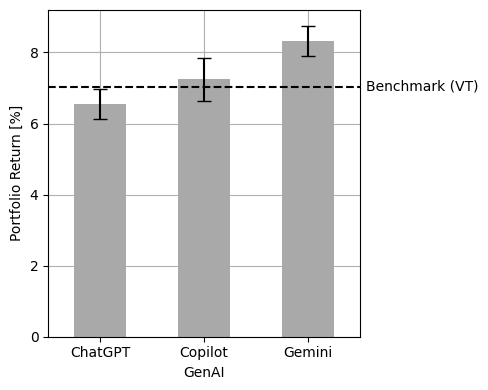

In [7]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'ai')

               sum_sq     df         F        PR(>F)
label     2006.958792    2.0  66.92375  2.763967e-24
Residual  4003.496468  267.0       NaN           NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  high    low   -6.678   0.0 -8.0385 -5.3175   True
  high medium  -3.3922   0.0 -4.7526 -2.0317   True
   low medium   3.2858   0.0  1.9253  4.6463   True
---------------------------------------------------
group: ('low',) got t: -14.25756549753222 p_value: 0.0 dfs: 89 benchmark: 7.0324
group: ('medium',) got t: 0.9608931812209787 p_value: 0.3392 dfs: 89 benchmark: 7.0324
group: ('high',) got t: 6.197732589469534 p_value: 0.0 dfs: 89 benchmark: 7.0324
means:
risk-taking
low        4.0510
medium     7.3368
high      10.7290
Name: portfolio_return, dtype: float64
stds:
risk-taking
low       1.9838
medium    3.0052
high      5.6583
Name: portfolio_return, dtype: float64
risk-tak

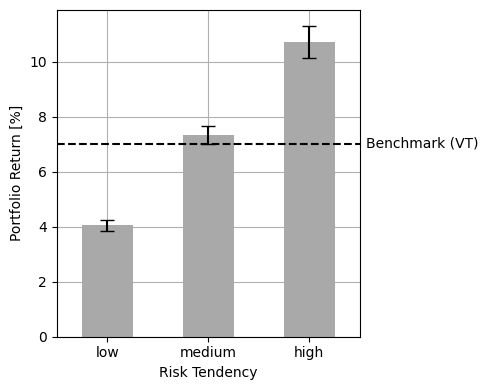

In [8]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]',  benchmark_return, 'Benchmark (VT)', 'risk-taking')

               sum_sq     df         F  PR(>F)
label      114.849594    1.0  5.220785  0.0231
Residual  5895.605666  268.0       NaN     NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   1.1756 0.2147 -0.4735 2.8246  False
    15     50    1.637 0.0522 -0.0121 3.2861  False
    30     50   0.4614 0.7871 -1.1876 2.1105  False
---------------------------------------------------
group: (15,) got t: -1.3542437248622547 p_value: 0.1791 dfs: 89 benchmark: 7.0324
group: (30,) got t: 1.265055037335122 p_value: 0.2092 dfs: 89 benchmark: 7.0324
group: (50,) got t: 1.80671219088405 p_value: 0.0742 dfs: 89 benchmark: 7.0324
means:
age
15    6.4348
30    7.6103
50    8.0718
Name: portfolio_return, dtype: float64
stds:
age
15    4.1869
30    4.3336
50    5.4573
Name: portfolio_return, dtype: float64
age
15    90
30    90
50    90
Name: portfolio_return, dtype: int64


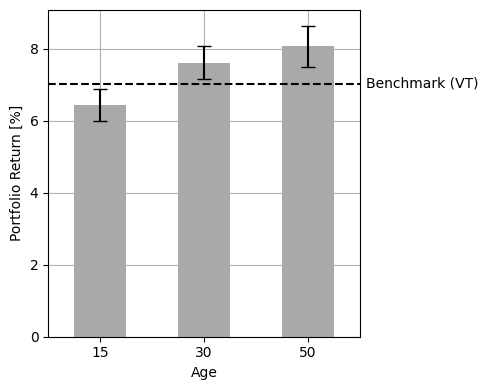

In [9]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'age')

               sum_sq     df          F        PR(>F)
label     3351.349604    8.0  41.118254  4.129297e-42
Residual  2659.105655  261.0        NaN           NaN
            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------------
  (ChatGPT, high)    (ChatGPT, low)  -2.2715 0.1339  -4.8494  0.3065  False
  (ChatGPT, high) (ChatGPT, medium)   2.4195 0.0851  -0.1585  4.9974  False
  (ChatGPT, high)   (Copilot, high)   7.8259    0.0    5.248 10.4038   True
  (ChatGPT, high)    (Copilot, low)  -3.8806 0.0001  -6.4586 -1.3027   True
  (ChatGPT, high) (Copilot, medium)  -1.7101 0.4927  -4.2881  0.8678  False
  (ChatGPT, high)    (Gemini, high)   4.8638    0.0   2.2859  7.4418   True
  (ChatGPT, high)     (Gemini, low)  -1.1921 0.8786    -3.77  1.3859  False
  (ChatGPT, high)  (Gemini, medium)   1.8039 0.4161   -0.774  4.3818  False
  

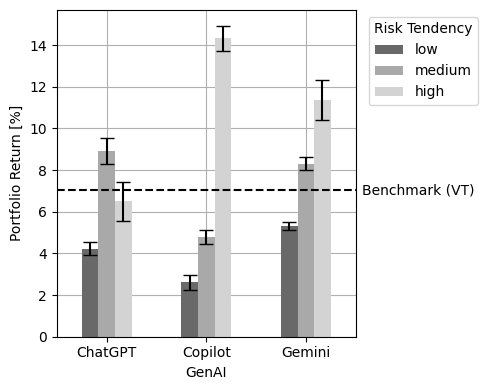

In [10]:
show_mean_errplot(portfolio_df, 'portfolio_return', 'Portfolio Return [%]', benchmark_return, 'Benchmark (VT)', 'ai', 'risk-taking')

### Portfolio Volatility

             sum_sq     df         F    PR(>F)
label      1.387924    2.0  2.816627  0.061586
Residual  65.783618  267.0       NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
ChatGPT Copilot  -0.1719 0.0543 -0.3463 0.0025  False
ChatGPT  Gemini  -0.0548 0.7395 -0.2292 0.1196  False
Copilot  Gemini   0.1171  0.255 -0.0573 0.2915  False
-----------------------------------------------------
group: ('ChatGPT',) got t: 5.1382217881296866 p_value: 0.0 dfs: 89 benchmark: 0.7562
group: ('Copilot',) got t: 1.220875225004765 p_value: 0.2254 dfs: 89 benchmark: 0.7562
group: ('Gemini',) got t: 4.7505818895903325 p_value: 0.0 dfs: 89 benchmark: 0.7562
means:
ai
ChatGPT    1.0066
Copilot    0.8347
Gemini     0.9518
Name: portfolio_std_dev, dtype: float64
stds:
ai
ChatGPT    0.4624
Copilot    0.6104
Gemini     0.3907
Name: portfolio_std_dev, dtype: float64
ai
ChatGPT    90
C

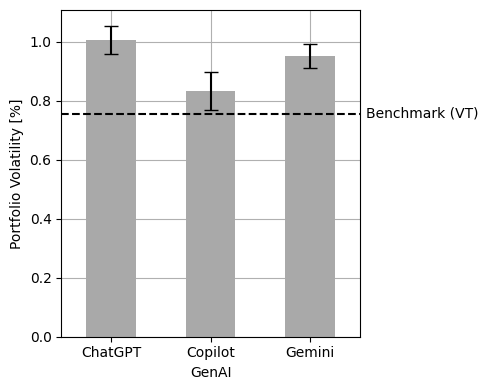

In [11]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'ai')

             sum_sq     df           F        PR(>F)
label     50.606597    2.0  407.848037  6.801856e-82
Residual  16.564946  267.0         NaN           NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  high    low  -1.0458   0.0 -1.1333 -0.9583   True
  high medium   -0.675   0.0 -0.7625 -0.5875   True
   low medium   0.3709   0.0  0.2833  0.4584   True
---------------------------------------------------
group: ('low',) got t: -14.471217690936124 p_value: 0.0 dfs: 89 benchmark: 0.7562
group: ('medium',) got t: 2.9195223435421775 p_value: 0.0044 dfs: 89 benchmark: 0.7562
group: ('high',) got t: 23.532077947588554 p_value: 0.0 dfs: 89 benchmark: 0.7562
means:
risk-taking
low       0.4588
medium    0.8297
high      1.5047
Name: portfolio_std_dev, dtype: float64
stds:
risk-taking
low       0.1949
medium    0.2389
high      0.3018
Name: portfolio_std_dev, dtype: float64
risk-ta

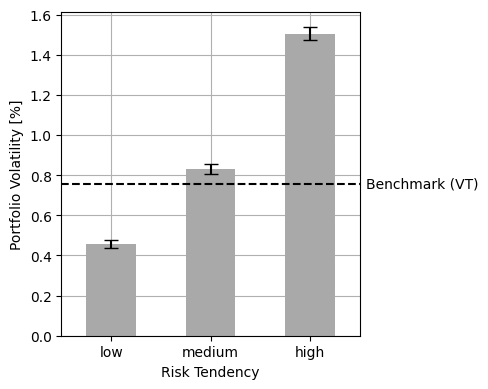

In [12]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'risk-taking')

             sum_sq     df         F    PR(>F)
label      0.042802    1.0  0.170878  0.679663
Residual  67.128741  268.0       NaN       NaN
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    15     30   0.0896 0.4517 -0.0858  0.265  False
    15     50  -0.0214 0.9555 -0.1968  0.154  False
    30     50   -0.111 0.2966 -0.2864 0.0644  False
---------------------------------------------------
group: (15,) got t: 2.8997734214074073 p_value: 0.0047 dfs: 89 benchmark: 0.7562
group: (30,) got t: 4.316688867424053 p_value: 0.0 dfs: 89 benchmark: 0.7562
group: (50,) got t: 2.658995047341389 p_value: 0.0093 dfs: 89 benchmark: 0.7562
means:
age
15    0.9083
30    0.9979
50    0.8869
Name: portfolio_std_dev, dtype: float64
stds:
age
15    0.4978
30    0.5313
50    0.4665
Name: portfolio_std_dev, dtype: float64
age
15    90
30    90
50    90
Name: portfolio_std_dev, dtype: int64


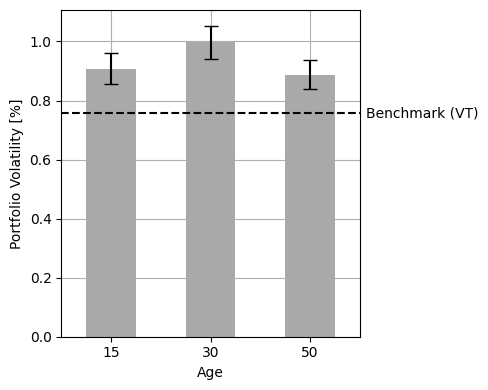

In [13]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'age')

             sum_sq     df           F        PR(>F)
label     54.840371    8.0  145.093031  1.798166e-91
Residual  12.331172  261.0         NaN           NaN
           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------
  (ChatGPT, high)    (ChatGPT, low)  -0.9768    0.0 -1.1523 -0.8012   True
  (ChatGPT, high) (ChatGPT, medium)   -0.601    0.0 -0.7766 -0.4255   True
  (ChatGPT, high)   (Copilot, high)   0.0718 0.9364 -0.1037  0.2474  False
  (ChatGPT, high)    (Copilot, low)  -1.2533    0.0 -1.4289 -1.0778   True
  (ChatGPT, high) (Copilot, medium)   -0.912    0.0 -1.0876 -0.7365   True
  (ChatGPT, high)    (Gemini, high)  -0.1555  0.129 -0.3311    0.02  False
  (ChatGPT, high)     (Gemini, low)  -0.9911    0.0 -1.1667 -0.8156   True
  (ChatGPT, high)  (Gemini, medium)  -0.5955    0.0 -0.7711   -0.42   True
   (ChatGPT, low

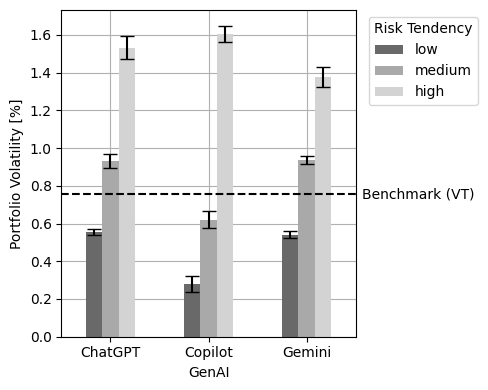

In [14]:
show_mean_errplot(portfolio_df, 'portfolio_std_dev', 'Portfolio Volatility [%]', benchmark_std, 'Benchmark (VT)', 'ai', 'risk-taking')

### Sharpe

In [15]:
print(portfolio_df.shape)
sharpe_df = portfolio_df.copy()
sharpe_df = sharpe_df.dropna()
print(sharpe_df.shape)

(270, 8)
(269, 8)


                 sum_sq     df         F    PR(>F)
label      10192.479950    2.0  8.747081  0.000209
Residual  154977.393315  266.0       NaN       NaN
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
ChatGPT Copilot -12.1549 0.0025 -20.6594 -3.6505   True
ChatGPT  Gemini   1.6894 0.8857  -6.7913 10.1701  False
Copilot  Gemini  13.8443 0.0005   5.3399 22.3488   True
-------------------------------------------------------
group: ('ChatGPT',) got t: -3.796058132320286 p_value: 0.0003 dfs: 89 benchmark: 3.6172
group: ('Copilot',) got t: -3.114167474540264 p_value: 0.0025 dfs: 88 benchmark: 3.6172
group: ('Gemini',) got t: 0.2804706256932688 p_value: 0.7798 dfs: 89 benchmark: 3.6172
means:
ai
ChatGPT     2.0288
Copilot   -10.1261
Gemini      3.7182
Name: sharpe, dtype: float64
stds:
ai
ChatGPT     3.9696
Copilot    41.6338
Gemini      3.4155
Name: sharpe, dtype: float64
a

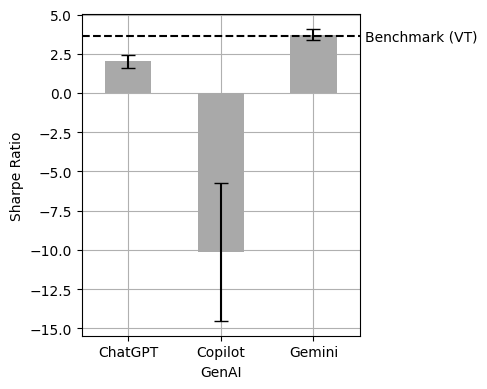

In [16]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'ai')

                 sum_sq     df          F    PR(>F)
label      14121.500231    2.0  12.434159  0.000007
Residual  151048.373034  266.0        NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
  high    low -16.1752    0.0 -24.5712 -7.7793   True
  high medium  -1.6942 0.8822 -10.0666  6.6783  False
   low medium  14.4811 0.0002   6.0851  22.877   True
-----------------------------------------------------
group: ('low',) got t: -3.522586215873218 p_value: 0.0007 dfs: 88 benchmark: 3.6172
group: ('medium',) got t: -1.6899404515297092 p_value: 0.0945 dfs: 89 benchmark: 3.6172
group: ('high',) got t: 2.104711320410519 p_value: 0.0381 dfs: 89 benchmark: 3.6172
means:
risk-taking
low      -11.6842
medium     2.7968
high       4.4910
Name: sharpe, dtype: float64
stds:
risk-taking
low       40.9795
medium     4.6055
high       3.9385
Name: sharpe, dtype: float64
risk-ta

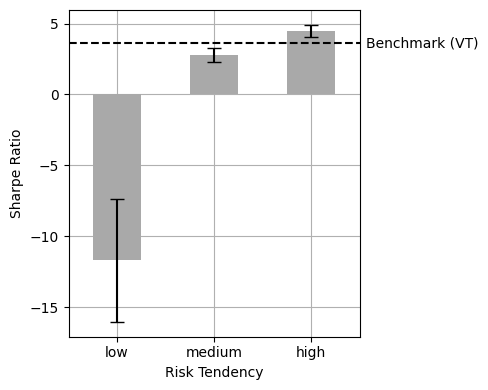

In [17]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'risk-taking')

                 sum_sq     df         F    PR(>F)
label         66.405453    1.0  0.107389  0.743394
Residual  165103.467812  267.0       NaN       NaN
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
    15     30  -3.9601 0.5345 -12.6961   4.776  False
    15     50  -1.5165 0.9124 -10.2771   7.244  False
    30     50   2.4436 0.7883   -6.317 11.2041  False
-----------------------------------------------------
group: (15,) got t: -5.0291045738542355 p_value: 0.0 dfs: 89 benchmark: 3.6172
group: (30,) got t: -2.0755441353496042 p_value: 0.0408 dfs: 89 benchmark: 3.6172
group: (50,) got t: -1.6388408218366273 p_value: 0.1048 dfs: 88 benchmark: 3.6172
means:
age
15    0.3992
30   -3.5609
50   -1.1173
Name: sharpe, dtype: float64
stds:
age
15     6.0705
30    32.8095
50    27.2544
Name: sharpe, dtype: float64
age
15    90
30    90
50    89
Name: sharpe, dtype: int64


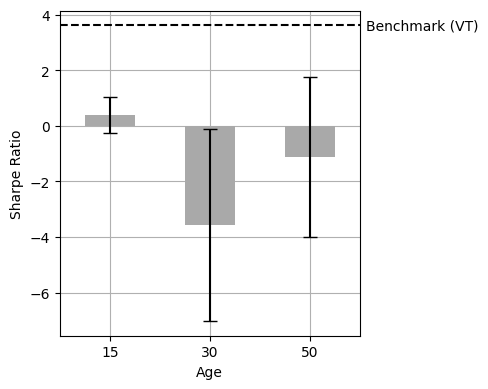

In [18]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'age')

                 sum_sq     df          F        PR(>F)
label      42606.118791    8.0  11.297784  1.007230e-13
Residual  122563.754474  260.0        NaN           NaN
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1            group2      meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------------
  (ChatGPT, high)    (ChatGPT, low)  -1.9981    1.0 -19.5343   15.538  False
  (ChatGPT, high) (ChatGPT, medium)   3.2871 0.9997  -14.249  20.8232  False
  (ChatGPT, high)   (Copilot, high)   4.8262 0.9947 -12.7099  22.3624  False
  (ChatGPT, high)    (Copilot, low) -38.5548    0.0 -56.2415 -20.8682   True
  (ChatGPT, high) (Copilot, medium)  -2.3416    1.0 -19.8777  15.1945  False
  (ChatGPT, high)    (Gemini, high)   3.8493 0.9989 -13.6869  21.3854  False
  (ChatGPT, high)     (Gemini, low)  -0.1397    1.0 -17.6758  17.3965  False
  (ChatGPT, high)  (Gemini, medium)   2.6475 0.9999 -14.8886  

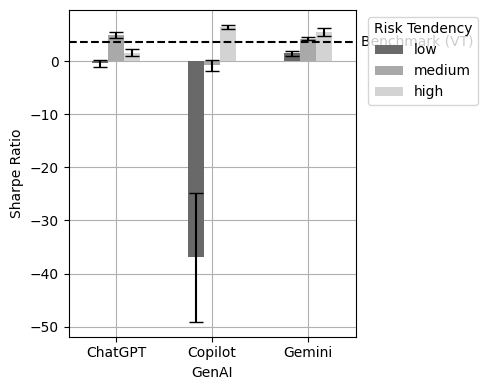

In [19]:
show_mean_errplot(sharpe_df, 'sharpe', 'Sharpe Ratio', benchmark_sharpe, 'Benchmark (VT)', 'ai', 'risk-taking')